In [1]:
import random
from collections import Counter

import spacy
from spacy.tokens import DocBin
from spacy.training import Example
from spacy.util import minibatch, compounding
from tqdm.auto import tqdm


print(f'spaCy {spacy.__version__}')

spaCy 3.8.14


In [3]:
nlp_blank = spacy.blank('ru')
for split, path in [('train', '../data/train_combo.spacy'), ('dev', '../data/dev_combo.spacy')]:
    db = DocBin().from_disk(path)
    docs = list(db.get_docs(nlp_blank.vocab))
    counts = Counter(e.label_ for d in docs for e in d.ents)
    n_ents = sum(len(d.ents) for d in docs)
    print(f'{split}: {len(docs)} docs, {n_ents} entities | {dict(counts)}')

train: 13052 docs, 11460 entities | {'NAME': 6298, 'ADDRESS': 5162}
dev: 1451 docs, 1264 entities | {'ADDRESS': 570, 'NAME': 694}


In [4]:
nlp = spacy.load('ru_core_news_lg')
print('Исходный пайплайн:', nlp.pipe_names)

# Оставляем только tok2vec, убираем всё остальное
for pipe in [p for p in nlp.pipe_names if p != 'tok2vec']:
    nlp.remove_pipe(pipe)

# Добавляем чистую NER-голову под наши два класса
ner = nlp.add_pipe('ner', last=True)
ner.add_label('NAME')
ner.add_label('ADDRESS')

print('Итоговый пайплайн:', nlp.pipe_names)
print('NER метки:', ner.labels)

Исходный пайплайн: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Итоговый пайплайн: ['tok2vec', 'ner']
NER метки: ('ADDRESS', 'NAME')


In [5]:
def load_examples(path, nlp):
    db = DocBin().from_disk(path)
    return [Example(nlp.make_doc(d.text), d) for d in db.get_docs(nlp.vocab)]

train_ex = load_examples('../data/train_combo_old.spacy', nlp)
dev_ex   = load_examples('../data/dev_combo_old.spacy', nlp)
print(f'train={len(train_ex)}  dev={len(dev_ex)}')

train=13052  dev=1451


In [15]:
N_EPOCHS = 5
DROPOUT  = 0.2
# DROPOUT  = 0.1
PATIENCE = 5

In [7]:
# initialize() сохраняет веса tok2vec (уже загружены из ru_core_news_lg),
# инициализирует только NER-голову
optimizer = nlp.initialize(lambda: train_ex)
optimizer.learn_rate = 5e-4

best_macro = 0.0
no_improve  = 0
history = {'loss': [], 'f_name': [], 'f_addr': [], 'macro': []}

In [21]:
for epoch in range(1, N_EPOCHS + 1):
    random.shuffle(train_ex)
    losses = {}
    # batches = list(minibatch(train_ex, size=compounding(4.0, 32.0, 1.001)))
    batches = list(minibatch(train_ex, size=compounding(8.0, 64.0, 1.001)))
    for batch in tqdm(batches, desc=f'Epoch {epoch:2d}', leave=False):
        nlp.update(batch, sgd=optimizer, drop=DROPOUT, losses=losses)

    sc = nlp.evaluate(dev_ex)
    pt = sc.get('ents_per_type', {})
    f_name = pt.get('NAME',    {}).get('f', 0.0)
    f_addr = pt.get('ADDRESS', {}).get('f', 0.0)
    macro  = (f_name + f_addr) / 2

    history['loss'].append(losses.get('ner', 0))
    history['f_name'].append(f_name)
    history['f_addr'].append(f_addr)
    history['macro'].append(macro)

    mark = ' ← best' if macro > best_macro else ''
    print(
        f'Epoch {epoch:2d} | loss={losses.get("ner", 0):7.1f} '
        f'| NAME={f_name:.3f}  ADDR={f_addr:.3f}  macro={macro:.3f}{mark}'
    )

    if macro > best_macro:
        best_macro = macro
        no_improve = 0
        nlp.to_disk('../models/model-best')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stop (patience={PATIENCE})')
            break

print(f'\nBest macro F1 = {best_macro:.3f}')

Epoch  1:   0%|          | 0/991 [00:00<?, ?it/s]

Epoch  1 | loss= 1823.5 | NAME=0.878  ADDR=0.773  macro=0.825
Early stop (patience=5)

Best macro F1 = 0.830


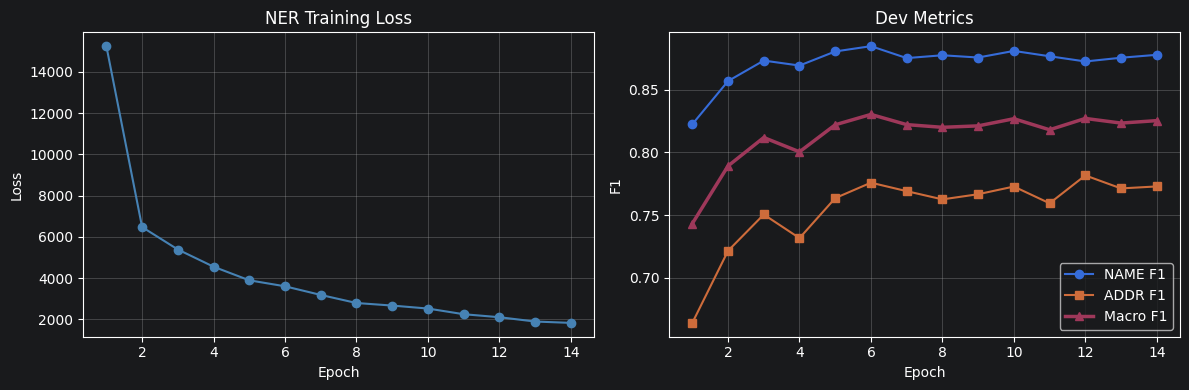

In [24]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history['loss']) + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['loss'], marker='o', color='steelblue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('NER Training Loss')
axes[0].grid(True, alpha=0.4)

axes[1].plot(epochs, history['f_name'], marker='o', label='NAME F1')
axes[1].plot(epochs, history['f_addr'], marker='s', label='ADDR F1')
axes[1].plot(epochs, history['macro'],  marker='^', label='Macro F1', linewidth=2.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].set_title('Dev Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [11]:
nlp_best = spacy.load('../models/model-best')
dev_ex_eval = load_examples('../data/dev_combo_old.spacy', nlp_best)
sc = nlp_best.evaluate(dev_ex_eval)
pt = sc.get('ents_per_type', {})

print('=== Dev-метрики (best model) ===')
for lbl in ('NAME', 'ADDRESS'):
    s = pt.get(lbl, {})
    print(f'  {lbl:8s}  P={s.get("p",0):.3f}  R={s.get("r",0):.3f}  F1={s.get("f",0):.3f}')
print(f'  {"Overall":8s}  P={sc["ents_p"]:.3f}  R={sc["ents_r"]:.3f}  F1={sc["ents_f"]:.3f}')

=== Dev-метрики (best model) ===
  NAME      P=0.874  R=0.896  F1=0.885
  ADDRESS   P=0.811  R=0.744  F1=0.776
  Overall   P=0.847  R=0.828  F1=0.837


In [12]:
nlp_best = spacy.load('../models/model-best')

TESTS = [
    'Иван Иванович Иванов живёт на улице Пушкина, д. 5',
    'Отправить документы Марии Петровне Соколовой: Санкт-Петербург, Невский пр., 10',
    'Контакт: Сидоров А.В., тел. +7 495 123-45-67',
    'Директор Соколова Е.М. переехала в г. Новосибирск, ул. Ленина, д. 12, кв. 34',
    'Паспорт выдан УФМС по г. Москве Прохорову Алексею Николаевичу',
]

for text in TESTS:
    doc = nlp_best(text)
    hi = text
    for ent in sorted(doc.ents, key=lambda e: e.start_char, reverse=True):
        hi = hi[:ent.start_char] + f'>>{ent.label_}:{hi[ent.start_char:ent.end_char]}<<' + hi[ent.end_char:]
    print(hi)

>>NAME:Иван Иванович Иванов<< живёт на >>ADDRESS:улице Пушкина, д. 5<<
Отправить документы >>NAME:Марии Петровне Соколовой<<: >>ADDRESS:Санкт-Петербург, Невский пр., 10<<
Контакт: >>NAME:Сидоров А.В.<<, тел. +7 495 123-45-67
Директор >>NAME:Соколова Е.М.<< переехала в >>ADDRESS:г. Новосибирск, ул. Ленина, д. 12, кв. 34<<
Паспорт выдан >>ADDRESS:УФМС<< по г. >>ADDRESS:Москве<< >>NAME:Прохорову Алексею Николаевичу<<


In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from collections import Counter

TARGET_LABELS = {'NAME', 'ADDRESS'}

# Загружаем бенчмарк (domain ≈ 900 примеров, entity ≈ 910 примеров)
pii_bench = load_dataset('raft-security-lab/pii-bench')

# Лучшая сохранённая модель
nlp_eval = spacy.load('../models/model-best')

def normalize(text: str) -> str:
    """Нормализация: убираем лишние пробелы + приводим к нижнему регистру."""
    return ' '.join(text.strip().split()).lower()

records = []

for subset_name, subset_data in pii_bench.items():
    for example in subset_data:
        text = example['text']

        # Инференс — прогоняем ВСЕ примеры (не только те, где есть NAME/ADDRESS)
        doc = nlp_eval(text)

        # Предсказания модели: только NAME и ADDRESS
        pred_bag = Counter(
            (normalize(ent.text), ent.label_)
            for ent in doc.ents
            if ent.label_ in TARGET_LABELS
        )

        # Золото: только NAME и ADDRESS из pii-bench (остальные типы игнорируем)
        gold_bag = Counter(
            (normalize(text[e['start']:e['end']]), e['type'])
            for e in example['entities']
            if e['type'] in TARGET_LABELS
        )

        # Bag-matching: TP = min(pred, gold) для каждой пары (текст, метка)
        for key in gold_bag | pred_bag:
            tp_cnt = min(gold_bag[key], pred_bag[key])
            fp_cnt = max(0, pred_bag[key] - gold_bag[key])
            fn_cnt = max(0, gold_bag[key] - pred_bag[key])
            label  = key[1]
            records += [{'subset': subset_name, 'label': label, 'decision': 'TP'}] * tp_cnt
            records += [{'subset': subset_name, 'label': label, 'decision': 'FP'}] * fp_cnt
            records += [{'subset': subset_name, 'label': label, 'decision': 'FN'}] * fn_cnt

df_results = pd.DataFrame(records) if records else pd.DataFrame(
    columns=['subset', 'label', 'decision'])


def build_metrics(df: pd.DataFrame, labels=TARGET_LABELS) -> pd.DataFrame:
    rows = []
    for label in sorted(labels):
        sub = df[df['label'] == label]
        tp  = int((sub['decision'] == 'TP').sum())
        fp  = int((sub['decision'] == 'FP').sum())
        fn  = int((sub['decision'] == 'FN').sum())
        p   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1  = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        rows.append({'label': label, 'TP': tp, 'FP': fp, 'FN': fn,
                     'Precision': round(p, 3), 'Recall': round(r, 3), 'F1': round(f1, 3)})
    # Macro-average только по меткам, где хоть что-то есть
    valid = [r for r in rows if r['TP'] + r['FP'] + r['FN'] > 0]
    if valid:
        rows.append({
            'label':     '__macro__',
            'TP':        sum(r['TP'] for r in valid),
            'FP':        sum(r['FP'] for r in valid),
            'FN':        sum(r['FN'] for r in valid),
            'Precision': round(float(np.mean([r['Precision'] for r in valid])), 3),
            'Recall':    round(float(np.mean([r['Recall']    for r in valid])), 3),
            'F1':        round(float(np.mean([r['F1']        for r in valid])), 3),
        })
    return pd.DataFrame(rows).set_index('label')


SEP = '=' * 55
for subset_name, subset_data in pii_bench.items():
    sub_df = df_results[df_results['subset'] == subset_name]
    print(f'{SEP}')
    print(f'  pii-bench / {subset_name}  ({len(subset_data)} примеров)')
    print(SEP)
    print(build_metrics(sub_df).to_string())

print(f'{SEP}')
print(f'  pii-bench / COMBINED  ({sum(len(v) for v in pii_bench.values())} примеров)')
print(SEP)
print(build_metrics(df_results).to_string())


  pii-bench / domain  (900 примеров)
            TP  FP  FN  Precision  Recall     F1
label                                           
ADDRESS     96  17  10      0.850   0.906  0.877
NAME       142   4  16      0.973   0.899  0.934
__macro__  238  21  26      0.911   0.903  0.905
  pii-bench / entity  (910 примеров)
            TP  FP  FN  Precision  Recall     F1
label                                           
ADDRESS     49  14  21      0.778   0.700  0.737
NAME        68   3   2      0.958   0.971  0.965
__macro__  117  17  23      0.868   0.835  0.851
  pii-bench / COMBINED  (1810 примеров)
            TP  FP  FN  Precision  Recall     F1
label                                           
ADDRESS    145  31  31      0.824   0.824  0.824
NAME       210   7  18      0.968   0.921  0.944
__macro__  355  38  49      0.896   0.873  0.884
